# Robust Gradient-Descent IMF

Standalone notebook for the smooth robust IMF method. The linear W/A commutativity result from `IMF.pdf` is used only as context for the mean-filter baseline; the robust gradient-descent smoother is nonlinear.


## Setup


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product

In [3]:
rng = np.random.default_rng(42)

n = 1000
t = np.linspace(0, 1, n)

sigma = 0.10

window_sizes = [151, 107, 75, 53, 37, 27, 19, 13]
kmax = len(window_sizes)

contamination_probs = [0.0, 0.01, 0.05, 0.10, 0.30, 0.50, 0.60]
contamination_scales = [0.5, 1.0, 2.0, 4.0]

n_repeats = 5

In [4]:
def gen_signal(t):
    slow = 0.6 * np.sin(2 * np.pi * t)
    medium = 0.25 * np.sin(12 * np.pi * t)
    bump = 0.8 * np.exp(-((t - 0.55) ** 2) / (2 * 0.015 ** 2))
    trend = 0.5 * (t - 0.5)

    x = slow + medium + bump + trend

    components = {
        "slow": slow,
        "medium": medium,
        "bump": bump,
        "trend": trend
    }

    return x, components

In [5]:
x_clean, true_components = gen_signal(t)


## Shared filtering utilities


In [6]:
def generate_observation(
    x,
    sigma=0.1,
    contamination_prob=0.05,
    contamination_scale=2.0,
    centered_contamination=False,
    rng=None,
):
    if rng is None:
        rng = np.random.default_rng()

    gaussian_noise = rng.normal(loc=0.0, scale=sigma, size=len(x))

    contamination_mask = rng.random(len(x)) < contamination_prob
    exponential_noise = rng.exponential(scale=contamination_scale, size=len(x))

    if centered_contamination:
        exponential_noise = exponential_noise - contamination_scale

    contamination = contamination_mask * exponential_noise

    y = x + gaussian_noise + contamination

    return y, {
        "gaussian_noise": gaussian_noise,
        "contamination": contamination,
        "contamination_mask": contamination_mask
    }

In [7]:
def epanechnikov_weights(window_size):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")

    radius = window_size // 2

    if radius == 0:
        return np.array([1.0])

    offsets = np.arange(-radius, radius + 1)
    u = offsets / radius

    weights = 0.75 * np.maximum(0, 1 - np.abs(u)) ** 2

    weights = weights / weights.sum()

    return weights

In [8]:
def local_mean_filter(y, window_size, boundary="wrap"):
    weights = epanechnikov_weights(window_size)
    radius = window_size // 2

    y_padded = np.pad(y, pad_width=radius, mode=boundary)

    out = np.empty_like(y, dtype=float)

    for i in range(len(y)):
        window = y_padded[i : i + window_size]
        out[i] = np.sum(weights * window)

    return out

def local_median_filter(y, window_size, boundary="wrap"):
    radius = window_size // 2

    y_padded = np.pad(y, pad_width=radius, mode=boundary)

    out = np.empty_like(y, dtype=float)

    for i in range(len(y)):
        window = y_padded[i : i + window_size]
        out[i] = np.median(window)

    return out

In [9]:
def weighted_median(values, weights):
    order = np.argsort(values)
    sorted_values = values[order]
    sorted_weights = weights[order]

    cumulative_weight = np.cumsum(sorted_weights)
    cutoff = 0.5 * sorted_weights.sum()

    idx = np.searchsorted(cumulative_weight, cutoff)

    return sorted_values[idx]

def local_weighted_median_filter(y, window_size, boundary="wrap"):
    weights = epanechnikov_weights(window_size)
    radius = window_size // 2

    y_padded = np.pad(y, pad_width=radius, mode=boundary)

    out = np.empty_like(y, dtype=float)

    for i in range(len(y)):
        window = y_padded[i : i + window_size]
        out[i] = weighted_median(window, weights)

    return out

In [10]:
def imf_decomposition(y, window_sizes, filter_fn, boundary="wrap"):
    residual = y.astype(float).copy()
    imfs = []

    for window_size in window_sizes:
        s_k = filter_fn(residual, window_size, boundary=boundary)
        imfs.append(s_k)
        residual = residual - s_k

    return {
        "imfs": np.array(imfs),
        "residual": residual,
        "reconstruction": np.array(imfs).sum(axis=0) + residual,
    }

In [11]:
def linear_imf(y, window_sizes):
    return imf_decomposition(
        y,
        window_sizes=window_sizes,
        filter_fn=local_mean_filter,
    )


def median_imf(y, window_sizes):
    return imf_decomposition(
        y,
        window_sizes=window_sizes,
        filter_fn=local_median_filter,
    )

def weighted_median_imf(y, window_sizes):
    return imf_decomposition(
        y,
        window_sizes=window_sizes,
        filter_fn=local_weighted_median_filter,
    )

## Baseline references for comparison


In [12]:
p_example = 0.2
scale_example = 2.0

y_example, noise_info = generate_observation(
    x_clean,
    sigma=sigma,
    contamination_prob=p_example,
    contamination_scale=scale_example,
    rng=np.random.default_rng(777),
)

linear_result = linear_imf(y_example, window_sizes)
median_result = median_imf(y_example, window_sizes)
weighted_median_result = weighted_median_imf(y_example, window_sizes)

In [13]:
linear_clean = linear_imf(x_clean, window_sizes)
median_clean = median_imf(x_clean, window_sizes)
weighted_median_clean = weighted_median_imf(x_clean, window_sizes)

In [14]:
def mse(a, b):
    return np.mean((a - b) ** 2)


def mae(a, b):
    return np.mean(np.abs(a - b))


def max_abs_error(a, b):
    return np.max(np.abs(a - b))


def summarize_decomposition_error(result_noisy, result_clean, method_name):
    rows = []

    imfs_noisy = result_noisy["imfs"]
    imfs_clean = result_clean["imfs"]

    for k in range(imfs_noisy.shape[0]):
        rows.append({
            "method": method_name,
            "component": f"imf_{k + 1}",
            "component_index": k + 1,
            "mse": mse(imfs_noisy[k], imfs_clean[k]),
            "mae": mae(imfs_noisy[k], imfs_clean[k]),
            "max_abs_error": max_abs_error(imfs_noisy[k], imfs_clean[k]),
        })

    rows.append({
        "method": method_name,
        "component": "residual",
        "component_index": len(window_sizes) + 1,
        "mse": mse(result_noisy["residual"], result_clean["residual"]),
        "mae": mae(result_noisy["residual"], result_clean["residual"]),
        "max_abs_error": max_abs_error(
            result_noisy["residual"],
            result_clean["residual"],
        ),
    })

    return rows

In [15]:
example_rows = []

example_rows.extend(
    summarize_decomposition_error(
        linear_result,
        linear_clean,
        method_name="linear_mean",
    )
)

example_rows.extend(
    summarize_decomposition_error(
        median_result,
        median_clean,
        method_name="median",
    )
)

example_rows.extend(
    summarize_decomposition_error(
        weighted_median_result,
        weighted_median_clean,
        method_name="weighted_median",
    )
)

example_error_df = pd.DataFrame(example_rows)

example_error_df

,method,component,component_index,mse,mae,max_abs_error
0,linear_mean,imf_1,1,0.127492,0.323875,0.751537
1,linear_mean,imf_2,2,0.004283,0.049577,0.258740
2,linear_mean,imf_3,3,0.003338,0.044913,0.277656
3,linear_mean,imf_4,4,0.003801,0.046618,0.320043
4,linear_mean,imf_5,5,0.005671,0.056071,0.388453
5,linear_mean,imf_6,6,0.008170,0.064261,0.512663
6,linear_mean,imf_7,7,0.011685,0.073181,0.735004
7,linear_mean,imf_8,8,0.020258,0.087775,1.220779
8,linear_mean,residual,9,0.695615,0.408230,9.229433
9,median,imf_1,1,0.005132,0.061001,0.216093


## Robust gradient-descent IMF

The PDF proves that the linear mean-filter operators commute on a regular wrap design. The robust smoother below is nonlinear, so that operator shortcut is kept as a linear baseline and validation point rather than applied to the robust decomposition.

In [16]:
import os
import time
from concurrent.futures import ThreadPoolExecutor
from numpy.lib.stride_tricks import sliding_window_view


SQRT_2 = np.sqrt(2.0)
SQRT_2_OVER_PI = np.sqrt(2.0 / np.pi)
DEFAULT_ROBUST_MAX_WORKERS = min(4, os.cpu_count() or 1)


def erf_approx(x):
    """Vectorized Abramowitz-Stegun approximation to erf(x)."""
    x = np.asarray(x, dtype=float)
    sign = np.sign(x)
    ax = np.abs(x)

    p = 0.3275911
    a1 = 0.254829592
    a2 = -0.284496736
    a3 = 1.421413741
    a4 = -1.453152027
    a5 = 1.061405429

    z = 1.0 / (1.0 + p * ax)
    poly = (((((a5 * z + a4) * z + a3) * z + a2) * z + a1) * z)
    return sign * (1.0 - poly * np.exp(-(ax ** 2)))


def smooth_abs_score(residual, H):
    """Derivative rho_H'(residual) for the PDF's smooth |x| contrast."""
    if H <= 0:
        raise ValueError("H must be positive")
    return erf_approx(residual / (SQRT_2 * H))


def smooth_abs_rho(residual, H):
    """Smooth |x| contrast from the Gaussian convolution formula in the PDF."""
    if H <= 0:
        raise ValueError("H must be positive")
    residual = np.asarray(residual, dtype=float)
    return (
        residual * smooth_abs_score(residual, H)
        + SQRT_2_OVER_PI * H * np.exp(-0.5 * (residual / H) ** 2)
    )


def robust_gd_fit_windows(windows, weights, H, max_iter=60, tol=1e-6):
    """Solve one robust local location problem per row of windows."""
    windows = np.asarray(windows, dtype=float)
    weights = np.asarray(weights, dtype=float)

    if windows.ndim != 2:
        raise ValueError("windows must be a 2D array")
    if H <= 0:
        raise ValueError("H must be positive")
    if len(windows) == 0:
        return np.array([], dtype=float)

    weights = weights / weights.sum()
    row_weights = weights.reshape(1, -1)

    x = np.median(windows, axis=1)
    lower = windows.min(axis=1)
    upper = windows.max(axis=1)

    # The gradient is globally Lipschitz with constant sqrt(2/pi) / H
    # because the Epanechnikov weights are normalized.
    step = 0.95 * H / SQRT_2_OVER_PI

    for _ in range(max_iter):
        local_score = np.sum(
            row_weights * smooth_abs_score(windows - x[:, None], H),
            axis=1,
        )
        x_next = np.clip(x + step * local_score, lower, upper)
        max_delta = float(np.max(np.abs(x_next - x)))
        x = x_next
        if max_delta <= tol * (1.0 + float(np.max(np.abs(x)))):
            break

    return x


def _robust_filter_chunk(args):
    start, stop, windows, weights, H, max_iter, tol = args
    return start, robust_gd_fit_windows(
        windows[start:stop],
        weights,
        H,
        max_iter=max_iter,
        tol=tol,
    )


def local_robust_gd_filter(
    y,
    window_size,
    H,
    boundary="wrap",
    max_iter=60,
    tol=1e-6,
    max_workers=1,
    chunk_size=None,
):
    if window_size % 2 == 0:
        raise ValueError("window_size must be odd")

    y = np.asarray(y, dtype=float)
    radius = window_size // 2
    weights = epanechnikov_weights(window_size)
    y_padded = np.pad(y, pad_width=radius, mode=boundary)
    windows = sliding_window_view(y_padded, window_size)

    n = len(y)
    max_workers = max(1, int(max_workers or 1))
    if chunk_size is None:
        chunk_size = n if max_workers == 1 else max(64, int(np.ceil(n / max_workers)))

    ranges = [(start, min(start + chunk_size, n)) for start in range(0, n, chunk_size)]

    if max_workers == 1 or len(ranges) == 1:
        return robust_gd_fit_windows(
            windows,
            weights,
            H,
            max_iter=max_iter,
            tol=tol,
        )

    out = np.empty(n, dtype=float)
    args = [
        (start, stop, windows, weights, H, max_iter, tol)
        for start, stop in ranges
    ]
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        for start, values in executor.map(_robust_filter_chunk, args):
            out[start:start + len(values)] = values

    return out


def robust_gd_imf(
    y,
    window_sizes,
    H,
    boundary="wrap",
    max_iter=60,
    tol=1e-6,
    max_workers=1,
):
    residual = np.asarray(y, dtype=float).copy()
    imfs = []

    for window_size in window_sizes:
        s_k = local_robust_gd_filter(
            residual,
            window_size,
            H,
            boundary=boundary,
            max_iter=max_iter,
            tol=tol,
            max_workers=max_workers,
        )
        imfs.append(s_k)
        residual = residual - s_k

    imfs = np.array(imfs)
    return {
        "imfs": imfs,
        "residual": residual,
        "reconstruction": imfs.sum(axis=0) + residual,
        "H": float(H),
    }


def timed_robust_gd_imf(*args, **kwargs):
    start = time.perf_counter()
    result = robust_gd_imf(*args, **kwargs)
    return result, time.perf_counter() - start


DEFAULT_ROBUST_MAX_WORKERS


4

### Robust example and H tuning

In [17]:
robust_H_grid = np.array([0.25, 0.5, 1.0, 2.0]) * sigma

robust_results_by_H = {}
robust_clean_by_H = {}
robust_example_rows = []
robust_timing_rows = []

for H in robust_H_grid:
    H_key = float(H)
    robust_result_for_H, elapsed = timed_robust_gd_imf(
        y_example,
        window_sizes,
        H=H_key,
        max_workers=DEFAULT_ROBUST_MAX_WORKERS,
    )
    robust_clean_for_H = robust_gd_imf(
        x_clean,
        window_sizes,
        H=H_key,
        max_workers=DEFAULT_ROBUST_MAX_WORKERS,
    )

    robust_results_by_H[H_key] = robust_result_for_H
    robust_clean_by_H[H_key] = robust_clean_for_H
    robust_timing_rows.append({"H": H_key, "seconds": elapsed})

    for row in summarize_decomposition_error(
        robust_result_for_H,
        robust_clean_for_H,
        method_name="robust_gd",
    ):
        row["H"] = H_key
        robust_example_rows.append(row)

robust_example_error_df = pd.DataFrame(robust_example_rows)
robust_timing_df = pd.DataFrame(robust_timing_rows)

robust_h_summary_df = (
    robust_example_error_df
    .groupby("H", as_index=False)
    .agg(
        mean_mse=("mse", "mean"),
        median_mse=("mse", "median"),
        mean_mae=("mae", "mean"),
        max_abs_error=("max_abs_error", "max"),
    )
    .merge(robust_timing_df, on="H")
    .sort_values("mean_mse")
)

best_H = float(robust_h_summary_df.iloc[0]["H"])
robust_result = robust_results_by_H[best_H]
robust_clean = robust_clean_by_H[best_H]

robust_reconstruction_error = np.max(
    np.abs(robust_result["reconstruction"] - y_example)
)

print("robust GD reconstruction max error:", robust_reconstruction_error)
print("best H by mean component MSE:", best_H)

robust_h_summary_df


robust GD reconstruction max error: 1.7763568394002505e-15
best H by mean component MSE: 0.2


,H,mean_mse,median_mse,mean_mae,max_abs_error,seconds
3,0.200,0.130063,0.000365,0.057932,13.419115,0.177702
2,0.100,0.135328,0.000396,0.055069,13.465742,0.236501
1,0.050,0.138200,0.000347,0.054504,13.476158,0.284628
0,0.025,0.139623,0.000315,0.054737,13.466762,0.296389


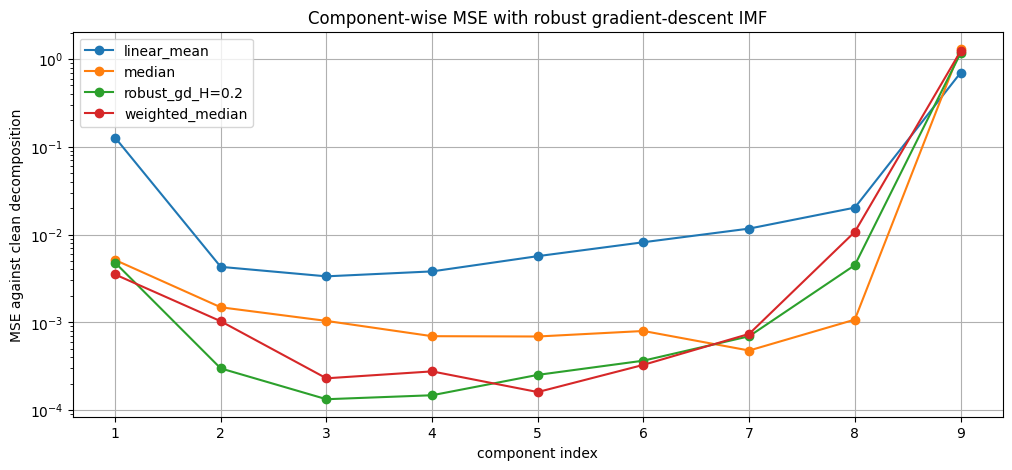

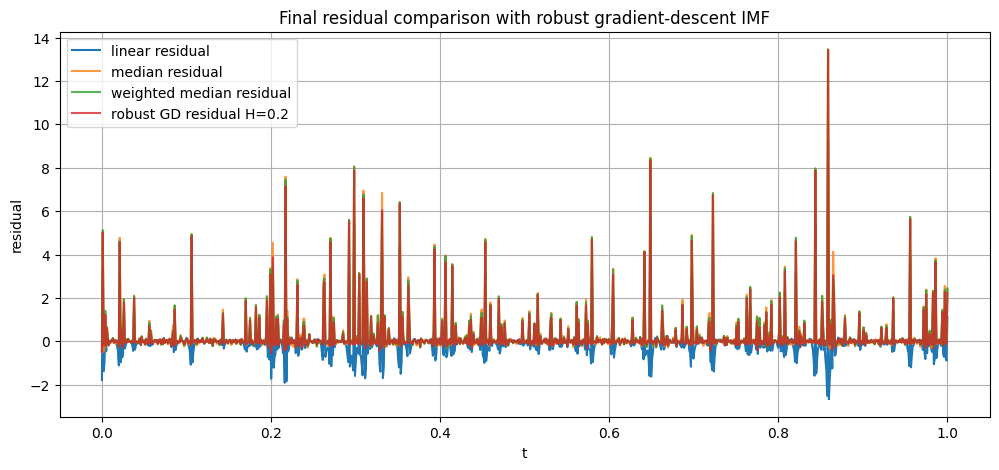

In [18]:
best_robust_example_df = robust_example_error_df[
    robust_example_error_df["H"] == best_H
].copy()
best_robust_example_df["method"] = f"robust_gd_H={best_H:.3g}"

combined_example_error_df = pd.concat(
    [
        example_error_df,
        best_robust_example_df.drop(columns=["H"]),
    ],
    ignore_index=True,
)

plt.figure(figsize=(12, 5))

for method_name, group in combined_example_error_df.groupby("method"):
    plt.plot(
        group["component_index"],
        group["mse"],
        marker="o",
        label=method_name,
    )

plt.yscale("log")
plt.title("Component-wise MSE with robust gradient-descent IMF")
plt.xlabel("component index")
plt.ylabel("MSE against clean decomposition")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, linear_result["residual"], label="linear residual")
plt.plot(t, median_result["residual"], label="median residual", alpha=0.8)
plt.plot(t, weighted_median_result["residual"], label="weighted median residual", alpha=0.8)
plt.plot(t, robust_result["residual"], label=f"robust GD residual H={best_H:.3g}", alpha=0.8)
plt.title("Final residual comparison with robust gradient-descent IMF")
plt.xlabel("t")
plt.ylabel("residual")
plt.legend()
plt.grid(True)
plt.show()


### Parallel benchmark

In [19]:
def aggregate_decomposition_error(error_rows):
    frame = pd.DataFrame(error_rows)
    return {
        "mean_mse": frame["mse"].mean(),
        "mean_mae": frame["mae"].mean(),
        "max_abs_error": frame["max_abs_error"].max(),
    }


def benchmark_row(method, p, scale, repeat, error_rows, H=np.nan):
    row = {
        "method": method,
        "H": H,
        "contamination_prob": p,
        "contamination_scale": scale,
        "repeat": repeat,
    }
    row.update(aggregate_decomposition_error(error_rows))
    return row


benchmark_probs = [0.0, 0.2, 0.5]
benchmark_scales = [2.0]
benchmark_repeats = 2

benchmark_cases = [
    (p_index, p, scale_index, scale, repeat)
    for p_index, p in enumerate(benchmark_probs)
    for scale_index, scale in enumerate(benchmark_scales)
    for repeat in range(benchmark_repeats)
]


def run_benchmark_case(case):
    p_index, p, scale_index, scale, repeat = case
    seed = 20_000 + 1_000 * p_index + 100 * scale_index + repeat
    y_trial, _ = generate_observation(
        x_clean,
        sigma=sigma,
        contamination_prob=p,
        contamination_scale=scale,
        rng=np.random.default_rng(seed),
    )

    rows = []

    baseline_specs = [
        ("linear_mean", linear_imf, linear_clean),
        ("median", median_imf, median_clean),
        ("weighted_median", weighted_median_imf, weighted_median_clean),
    ]

    for method_name, method_fn, clean_reference in baseline_specs:
        result = method_fn(y_trial, window_sizes)
        error_rows = summarize_decomposition_error(
            result,
            clean_reference,
            method_name=method_name,
        )
        rows.append(benchmark_row(method_name, p, scale, repeat, error_rows))

    for H in robust_H_grid:
        H_key = float(H)
        result = robust_gd_imf(
            y_trial,
            window_sizes,
            H=H_key,
            max_workers=1,
        )
        error_rows = summarize_decomposition_error(
            result,
            robust_clean_by_H[H_key],
            method_name="robust_gd",
        )
        rows.append(benchmark_row("robust_gd", p, scale, repeat, error_rows, H=H_key))

    return rows


benchmark_start = time.perf_counter()
with ThreadPoolExecutor(max_workers=DEFAULT_ROBUST_MAX_WORKERS) as executor:
    benchmark_parts = list(executor.map(run_benchmark_case, benchmark_cases))
benchmark_seconds = time.perf_counter() - benchmark_start

benchmark_rows = [row for part in benchmark_parts for row in part]
benchmark_df = pd.DataFrame(benchmark_rows)

benchmark_summary_df = (
    benchmark_df
    .groupby(["method", "H"], dropna=False, as_index=False)
    .agg(
        mean_mse=("mean_mse", "mean"),
        mean_mae=("mean_mae", "mean"),
        max_abs_error=("max_abs_error", "max"),
    )
    .sort_values("mean_mse")
)

best_benchmark_H = float(
    benchmark_summary_df[benchmark_summary_df["method"] == "robust_gd"].iloc[0]["H"]
)

print("benchmark cases:", len(benchmark_cases))
print("benchmark seconds:", benchmark_seconds)
print("best benchmark H:", best_benchmark_H)

benchmark_summary_df


benchmark cases: 6
benchmark seconds: 5.891673047999575
best benchmark H: 0.2


,method,H,mean_mse,mean_mae,max_abs_error
0,linear_mean,NaN,0.147640,0.149890,13.938077
5,robust_gd,0.200,0.158649,0.080961,19.577206
4,robust_gd,0.100,0.165627,0.078211,19.873703
6,weighted_median,NaN,0.171173,0.077757,19.061975
3,robust_gd,0.050,0.171660,0.077951,20.285899
2,robust_gd,0.025,0.176688,0.079443,19.925459
1,median,NaN,0.198401,0.097925,19.826245


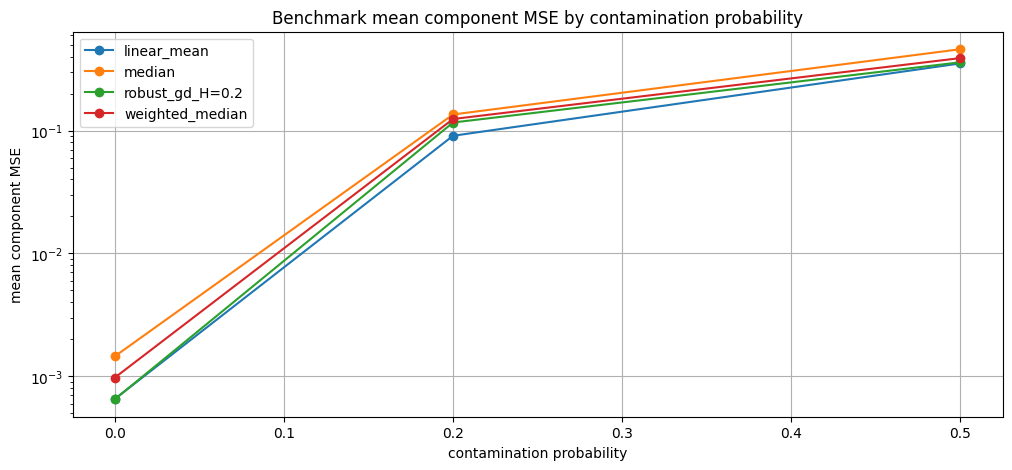

,mode,workers,seconds
0,sequential local fits,1,0.319955
1,threaded local fits,4,0.194999


In [20]:
benchmark_plot_df = benchmark_df[
    (benchmark_df["method"] != "robust_gd")
    | (benchmark_df["H"] == best_benchmark_H)
].copy()

benchmark_plot_df["label"] = benchmark_plot_df.apply(
    lambda row: f"robust_gd_H={row['H']:.3g}"
    if row["method"] == "robust_gd"
    else row["method"],
    axis=1,
)

benchmark_curve_df = (
    benchmark_plot_df
    .groupby(["label", "contamination_prob"], as_index=False)
    .agg(mean_mse=("mean_mse", "mean"))
)

plt.figure(figsize=(12, 5))

for label, group in benchmark_curve_df.groupby("label"):
    plt.plot(
        group["contamination_prob"],
        group["mean_mse"],
        marker="o",
        label=label,
    )

plt.yscale("log")
plt.title("Benchmark mean component MSE by contamination probability")
plt.xlabel("contamination probability")
plt.ylabel("mean component MSE")
plt.legend()
plt.grid(True)
plt.show()

sequential_result, sequential_seconds = timed_robust_gd_imf(
    y_example,
    window_sizes,
    H=best_H,
    max_workers=1,
)
parallel_result, parallel_seconds = timed_robust_gd_imf(
    y_example,
    window_sizes,
    H=best_H,
    max_workers=DEFAULT_ROBUST_MAX_WORKERS,
)

robust_speed_df = pd.DataFrame([
    {"mode": "sequential local fits", "workers": 1, "seconds": sequential_seconds},
    {"mode": "threaded local fits", "workers": DEFAULT_ROBUST_MAX_WORKERS, "seconds": parallel_seconds},
])

robust_speed_df
